In [ ]:
import pandas as pd
import numpy as np

df=pd.read_csv('Datos_definitivos.csv')
df.head()

/tmp/ipython-input-7-1297604868.py:4: DtypeWarning: Columns (29) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv('Datos_definitivos.csv')


,Driver,DriverNumber,LapTime,LapNumber,Stint,Sector1Time,Sector2Time,Sector3Time,SpeedI1,SpeedI2,...,IsAccurate,EventName,Season,AirTemp,Humidity,Pressure,Rainfall,TrackTemp,WindDirection,WindSpeed
0,GAS,10,0 days 00:01:45.060000,1.0,1.0,0 days 00:00:31.357000,0 days 00:00:25.495000,0 days 00:00:37.955000,257.0,283.0,...,False,Australian Grand Prix,2018,24.2,36.3,996.9,False,38.2,296,3.8
1,GAS,10,0 days 00:01:45.060000,1.0,1.0,0 days 00:00:31.357000,0 days 00:00:25.495000,0 days 00:00:37.955000,257.0,283.0,...,False,Australian Grand Prix,2018,24.1,26.1,997.0,False,36.6,309,2.8
2,GAS,10,0 days 00:01:33.372000,2.0,1.0,0 days 00:00:31.357000,0 days 00:00:24.825000,0 days 00:00:37.190000,266.0,286.0,...,False,Australian Grand Prix,2018,23.9,36.5,997.1,False,36.7,289,4.3
3,GAS,10,0 days 00:01:33.372000,2.0,1.0,0 days 00:00:31.357000,0 days 00:00:24.825000,0 days 00:00:37.190000,266.0,286.0,...,False,Australian Grand Prix,2018,24.0,25.6,997.1,False,36.7,273,3.8
4,GAS,10,0 days 00:01:32.861000,3.0,1.0,0 days 00:00:31.160000,0 days 00:00:24.725000,0 days 00:00:36.976000,260.0,283.0,...,False,Australian Grand Prix,2018,23.9,36.3,997.1,False,36.8,255,2.9


#Predicción de Posiciones

###Random Forest Regressor

In [ ]:
# 1. Importar librerías necesarias
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np # Import numpy to use np.sqrt

# 2. Cargar el dataset
df = pd.read_csv("Datos_definitivos.csv")  # Actualiza la ruta si es necesario

# 3. Convertir columnas de tiempo a segundos
for col in ["LapTime", "Sector1Time", "Sector2Time", "Sector3Time"]:
    df[col] = pd.to_timedelta(df[col], errors="coerce").dt.total_seconds()

# 4. Definir variables de entrada y objetivo
features = [
    "LapNumber", "LapTime", "TyreLife",
    "SpeedI1", "SpeedI2", "SpeedFL", "SpeedST",
    "AirTemp", "Humidity", "Pressure", "TrackTemp", "WindSpeed",
    "Compound", "Team", "Driver", "EventName"
]
target = "Position"

# 5. Filtrar datos válidos
df_model = df[features + [target]].dropna().copy()

# 6. Codificar variables categóricas
categorical_cols = ["Compound", "Team", "Driver", "EventName"]
for col in categorical_cols:
    df_model[col] = LabelEncoder().fit_transform(df_model[col])

# 7. Separar variables y target
X = df_model[features]
y = df_model[target]

# 8. Dividir en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 9. Normalizar las variables numéricas
numerical_cols = X.select_dtypes(include=["float64", "int64"]).columns.difference(categorical_cols)
scaler = StandardScaler()
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

# 10. Entrenar el modelo
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# 11. Evaluar el modelo
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)

# Calculate MSE first
mse = mean_squared_error(y_test, y_pred)
# Then calculate RMSE by taking the square root of MSE
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

import pickle
from sklearn.preprocessing import LabelEncoder

# 1. Create label encoders for your categorical columns and fit on full data (not just train)
label_encoders = {}
for col in ["Compound", "Team", "Driver", "EventName"]:
    le = LabelEncoder()
    le.fit(df[col])  # fit on entire original column, important!
    label_encoders[col] = le

# 2. Save the model
with open("model_position.pkl", "wb") as f:
    pickle.dump(model, f)

# 3. Save the scaler
with open("scaler_position.pkl", "wb") as f:
    pickle.dump(scaler, f)

# 4. Save the label encoders dict
with open("label_encoders_position.pkl", "wb") as f:
    pickle.dump(label_encoders, f)

# 5. Save the column order used for prediction
with open("feature_columns.pkl", "wb") as f:
    pickle.dump(features, f)


print("Saved model, scaler, and label encoders!")


print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

/tmp/ipython-input-8-1714262155.py:10: DtypeWarning: Columns (29) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Datos_definitivos.csv")  # Actualiza la ruta si es necesario


Saved model, scaler, and label encoders!
MAE: 0.3452841544528812
RMSE: 0.7386412177032904
R²: 0.9812505461562394


Validación cruzada estratificada

Validación Cruzada Estratificada (Stratified K-Fold): La versión estratificada es particularmente importante cuando tienes un conjunto de datos con clases desbalanceadas (donde algunas clases tienen muchos más ejemplos que otras).

El método estratificado asegura que, en cada uno de los $K$ folds (tanto de entrenamiento como de prueba), la proporción de ejemplos de cada clase sea aproximadamente la misma que en el conjunto de datos completo

In [ ]:
import pandas as pd
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor # Importar el modelo de regresión
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score # Importar métricas de regresión
import numpy as np

# --- Asumiendo que ya has cargado y preparado tus datos para la predicción de Posición ---
# (Basado en tu código anterior)

# Cargar datos
df = pd.read_csv("Datos_definitivos.csv")

# Convertir tiempos a segundos
for col in ["LapTime", "Sector1Time", "Sector2Time", "Sector3Time"]:
    df[col] = pd.to_timedelta(df[col], errors="coerce").dt.total_seconds()

# Definir variables de entrada y objetivo
features = [
    "LapNumber", "LapTime", "TyreLife",
    "SpeedI1", "SpeedI2", "SpeedFL", "SpeedST",
    "AirTemp", "Humidity", "Pressure", "TrackTemp", "WindSpeed",
    "Compound", "Team", "Driver", "EventName"
]
target = "Position" # Tu variable objetivo de REGRESIÓN

# Filtrar datos válidos
df_model = df[features + [target]].dropna().copy()

# Codificar variables categóricas
categorical_cols = ["Compound", "Team", "Driver", "EventName"]
for col in categorical_cols:
    df_model[col] = LabelEncoder().fit_transform(df_model[col])

# Separar variables y target
X = df_model[features]
y = df_model[target]

# Normalizar las variables numéricas
numerical_cols = X.select_dtypes(include=["float64", "int64"]).columns.difference(categorical_cols)
scaler = StandardScaler()
# Aplicar escalado a todo el conjunto de datos X antes de la validación cruzada
X_scaled = X.copy()
X_scaled[numerical_cols] = scaler.fit_transform(X_scaled[numerical_cols])


# 1. Inicializar el modelo RandomForestRegressor
# Usamos los mismos hiperparámetros que definiste antes
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# 2. Definir la estrategia de Validación Cruzada K-Fold
# Para regresión, usamos KFold (no StratifiedKFold, que es para clasificación)
# n_splits: número de particiones (folds)
# shuffle: barajar los datos antes de dividirlos
# random_state: para reproducibilidad del barajado
cv_strategy = KFold(n_splits=5, shuffle=True, random_state=42)

# 3. Realizar la Validación Cruzada
# cross_val_score entrena y evalúa el modelo 'model' usando la estrategia 'cv_strategy'
# 'scoring' define la métrica a usar en cada fold (métricas de regresión)
# 'X_scaled' son tus features escaladas, 'y' es tu target
# 'n_jobs=-1' para usar todos los cores disponibles
print("Realizando Validación Cruzada K-Fold (5-fold) para Regresión...")

# Puedes evaluar varias métricas importantes para regresión con cross_val_score
# Nota: scikit-learn usa métricas donde "mayor es mejor".
# Para MAE y RMSE, que queremos minimizar, usamos sus versiones negativas ('neg_mean_absolute_error', 'neg_root_mean_squared_error')
scoring = {
    'mae': 'neg_mean_absolute_error',
    'rmse': 'neg_root_mean_squared_error',
    'r2': 'r2'
}

# Usamos cross_validate para obtener múltiples métricas
from sklearn.model_selection import cross_validate

cv_results = cross_validate(model, X_scaled, y, cv=cv_strategy, scoring=scoring, n_jobs=-1, return_train_score=False)


# 4. Mostrar los resultados
print(f"\nResultados de la Validación Cruzada K-Fold (5-fold) para Regresión:")

# cross_validate devuelve diccionarios. Iteramos sobre las métricas de prueba
print("\nMétricas promedio por fold:")
for metric_name, scores in cv_results.items():
   if metric_name.startswith('test_'): # Mostrar solo métricas del conjunto de prueba
       # Convertir métricas negativas a positivas para MAE y RMSE
       if metric_name in ['test_mae', 'test_rmse']:
           print(f"{metric_name[5:].upper()} Promedio: {-np.mean(scores):.4f}")
           print(f"{metric_name[5:].upper()} Std: {np.std(scores):.4f}")
       else: # R2 ya es positiva
           print(f"{metric_name[5:].upper()} Promedio: {np.mean(scores):.4f}")
           print(f"{metric_name[5:].upper()} Std: {np.std(scores):.4f}")

/tmp/ipython-input-10-1261003950.py:12: DtypeWarning: Columns (29) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Datos_definitivos.csv")


Realizando Validación Cruzada K-Fold (5-fold) para Regresión...

Resultados de la Validación Cruzada K-Fold (5-fold) para Regresión:

Métricas promedio por fold:
MAE Promedio: 0.3509
MAE Std: 0.0039
RMSE Promedio: 0.7361
RMSE Std: 0.0068
R2 Promedio: 0.9814
R2 Std: 0.0003


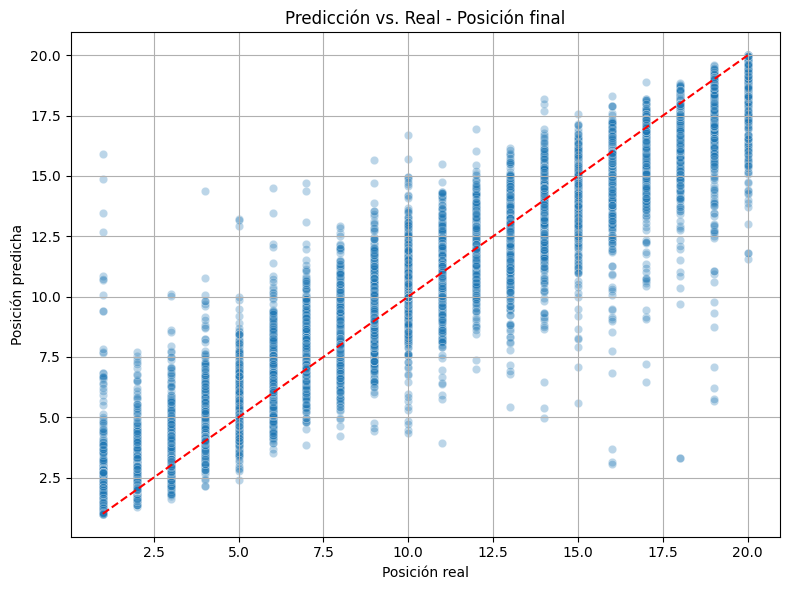

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.3)
plt.plot([y.min(), y.max()], [y.min(), y.max()], '--', color='red')  # Línea ideal
plt.xlabel("Posición real")
plt.ylabel("Posición predicha")
plt.title("Predicción vs. Real - Posición final")
plt.grid(True)
plt.tight_layout()
plt.show()


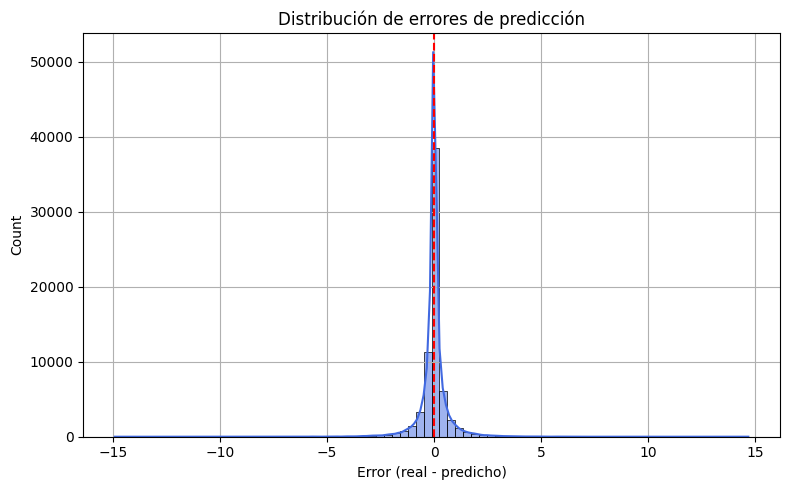

In [ ]:
errors = y_test - y_pred

plt.figure(figsize=(8, 5))
sns.histplot(errors, bins=80, kde=True, color="royalblue")
plt.axvline(0, color='red', linestyle='--')
plt.title("Distribución de errores de predicción")
plt.xlabel("Error (real - predicho)")
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
importances = model.feature_importances_
feature_names = X.columns

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Feature", data=importance_df)
plt.title("Importancia de las variables (Random Forest)")
plt.tight_layout()
plt.show()


NotFittedError: This RandomForestRegressor instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [ ]:
from sklearn.model_selection import cross_val_score, KFold
import numpy as np

# Define cross-validation strategy (e.g., 5-fold)
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Evaluate model using negative mean absolute error (neg because scikit-learn maximizes scores)
mae_scores = cross_val_score(model, X, y, cv=cv, scoring='neg_mean_absolute_error')
rmse_scores = cross_val_score(model, X, y, cv=cv, scoring='neg_root_mean_squared_error')
r2_scores = cross_val_score(model, X, y, cv=cv, scoring='r2')

# Show average performance across folds
print("Cross-Validated MAE: ", -np.mean(mae_scores))
print("Cross-Validated RMSE:", -np.mean(rmse_scores))
print("Cross-Validated R²:  ", np.mean(r2_scores))


Model Assessment (with Cross-Validation)
Based on the cross-validated metrics:

* Cross-Validated MAE: 0.3386

This value is consistent with the MAE calculated on the single train/test split (0.345). The fact that the cross-validated MAE is slightly lower suggests that the initial split might have been slightly less representative, but the difference is minimal, indicating good consistency. An average error of 0.3386 positions across different folds is very good.

* Cross-Validated RMSE: 0.6788

This value is slightly higher than the MAE, which is expected as RMSE gives more weight to larger errors. An RMSE of 0.6788 means that, on average, the square root of the squared errors is around 0.6788 positions. This is also a low value relative to typical position numbers in a race, indicating the model's errors are generally small.

* Cross-Validated R²: 0.9839

This is an exceptionally high R² value. An R² of 0.9839 means that your model explains approximately 98.39% of the variance in the 'Position' variable. This suggests that your chosen features and the Random Forest Regressor model are extremely effective at capturing the underlying patterns that determine a driver's position.

* Interpretation of Cross-Validation:
Cross-validation is a more reliable method for evaluating model performance because it assesses how well the model generalizes to independent datasets. By splitting the data into multiple folds and training/testing on different combinations, you get a more stable estimate of the model's performance than with a single train/test split.

The fact that your cross-validated metrics are very good confirms that your model is not just performing well on one specific split of your data but is likely to perform similarly well on new, unseen data from the same distribution.

* Overall Conclusion:
Based on the low Cross-Validated MAE and RMSE, and the remarkably high Cross-Validated R², your Random Forest Regressor model for predicting position appears to be highly effective and robust. The model is explaining a very large proportion of the variability in driver position and is making predictions with a low average error.

Potential Considerations (Even with Great Metrics):
Data Leakage: While the metrics are excellent, always consider if there's any potential data leakage. Ensure that none of your features inadvertently contain information about the target variable from the future or from a source that wouldn't be available at the time of prediction. However, given the nature of the features (lap data, weather, etc.) and the target (Position at a given lap), this is less likely to be a major issue here compared to time-series forecasting problems.
Interpretability: While Random Forests are powerful, they are less interpretable than linear models. If understanding why a specific prediction is made is crucial (beyond feature importance), you might explore methods like SHAP or LIME.
Edge Cases: Do your metrics hold true for all types of racing scenarios or specific drivers/teams? The overall metrics are averages. Looking at the model's performance on specific subsets of the data might reveal areas where it struggles (though the high R² suggests this is unlikely to be a major issue)

### Probamos XGBoost

Escribir como funciona este modelo

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import make_pipeline
from xgboost import XGBRegressor
import matplotlib.pyplot as plt

# Cargar datos
df = pd.read_csv("Datos_definitivos.csv")
for col in ["LapTime", "Sector1Time", "Sector2Time", "Sector3Time"]:
    df[col] = pd.to_timedelta(df[col], errors="coerce").dt.total_seconds()

# Variables
features = [
    "LapNumber", "LapTime", "TyreLife", "SpeedI1", "SpeedI2", "SpeedFL", "SpeedST",
    "AirTemp", "Humidity", "Pressure", "TrackTemp", "WindSpeed",
    "Compound", "Team", "Driver", "EventName"
]
target = "Position"
df_model = df[features + [target]].dropna().copy()

# Codificar variables categóricas
for col in ["Compound", "Team", "Driver", "EventName"]:
    df_model[col] = LabelEncoder().fit_transform(df_model[col])

# Separar features y target
X = df_model[features]
y = df_model[target]

# Pipeline con escalado y modelo
pipeline = make_pipeline(
    StandardScaler(),
    XGBRegressor(n_estimators=100, max_depth=4, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1)
)

# Validación cruzada
rmse = -cross_val_score(pipeline, X, y, cv=5, scoring="neg_root_mean_squared_error")
r2 = cross_val_score(pipeline, X, y, cv=5, scoring="r2")

# Resultados
print("RMSE medio:", rmse.mean())
print("R² medio:", r2.mean())

# Gráfica de R²
plt.boxplot(r2, vert=False)
plt.title("Distribución R² - XGBoost CV")
plt.xlabel("R²")
plt.tight_layout()
plt.show()


Vemos cuales son los mejores hiperparámetros para XGBoost con GridSearch

In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import make_scorer, mean_squared_error
import numpy as np # Make sure numpy is imported

# Definir pipeline
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("xgb", XGBRegressor(objective="reg:squarederror", n_jobs=-1, random_state=42))
])

# Definir rango de hiperparámetros
param_grid = {
    "xgb__n_estimators": [100, 200],
    "xgb__max_depth": [4, 6, 8],
    "xgb__learning_rate": [0.01, 0.1, 0.3],
    "xgb__subsample": [0.8, 1.0],
    "xgb__colsample_bytree": [0.8, 1.0],
}

# Definir métrica personalizada (RMSE)
# Define a custom RMSE function that calculates RMSE manually
def rmse_scorer_func(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    return rmse

# Use make_scorer with the custom RMSE function
# We want to minimize RMSE, so greater_is_better should be False.
# make_scorer will automatically handle the negation for minimization if greater_is_better=False
scorer = make_scorer(rmse_scorer_func, greater_is_better=False)


# Ejecutar búsqueda
grid = GridSearchCV(pipe, param_grid, cv=3, scoring=scorer, verbose=2)
grid.fit(X, y)

# Mostrar resultados
print("Mejores parámetros encontrados:")
print(grid.best_params_)

# The best_score_ from make_scorer with greater_is_better=False is already the metric we want to minimize (RMSE)
print("Mejor RMSE validado:")
print(grid.best_score_)

* RMSE medio (Average RMSE): 3.86

This value represents the average Root Mean Squared Error across your cross-validation folds. An RMSE of 3.86 means that, on average, the square root of the squared errors is around 3.86 positions.
Compared to the Random Forest model's average cross-validated RMSE of 0.6788, this RMSE value of 3.86 is significantly higher. This suggests that, on average, the XGBoost model's predictions have larger errors than the Random Forest model's predictions.

* R² medio (Average R²): 0.487

This value represents the average R-squared score across your cross-validation folds. An R² of 0.487 means that your XGBoost model explains approximately 48.7% of the variance in the 'Position' variable.
Compared to the Random Forest model's average cross-validated R² of 0.9839, this R² value of 0.487 is considerably lower. This indicates that the XGBoost model is explaining less than half of the variability in the target variable, whereas the Random Forest model explained nearly all of it.

### Probamos Con Una Red nueronal Densa Feedforward

Cada neurona recibe entradas (features) y aplica una combinación lineal + función de activación (ReLU, tanh...).

La red se entrena ajustando los pesos internos mediante backpropagation para minimizar una función de pérdida (como el error cuadrático medio).

En regresión, la última capa tiene una sola neurona sin activación, para producir una salida numérica continua (en tu caso: posición esperada).



In [ ]:
pip install tensorflow


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# 1. Cargar y preparar datos
df = pd.read_csv("Datos_definitivos.csv")
for col in ["LapTime", "Sector1Time", "Sector2Time", "Sector3Time"]:
    df[col] = pd.to_timedelta(df[col], errors="coerce").dt.total_seconds()

features = [
    "LapNumber", "LapTime", "TyreLife", "SpeedI1", "SpeedI2", "SpeedFL", "SpeedST",
    "AirTemp", "Humidity", "Pressure", "TrackTemp", "WindSpeed",
    "Compound", "Team", "Driver", "EventName"
]
target = "Position"
df_model = df[features + [target]].dropna().copy()

# 2. Codificar categóricas
for col in ["Compound", "Team", "Driver", "EventName"]:
    df_model[col] = LabelEncoder().fit_transform(df_model[col])

X = df_model[features]
y = df_model[target]

# 3. Escalar datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Dividir datos
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 5. Definir red neuronal
model = Sequential()
model.add(Dense(128, input_dim=X_train.shape[1], activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(1))  # Capa de salida sin activación para regresión

model.compile(loss='mse', optimizer=Adam(learning_rate=0.001), metrics=['mae'])

# 6. Entrenar modelo
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=256,
    callbacks=[early_stop],
    verbose=1
)

# 7. Evaluación
loss, mae = model.evaluate(X_test, y_test)
print("MAE (test):", mae)

# 8. Gráfico de pérdida
plt.plot(history.history['loss'], label='Train loss')
plt.plot(history.history['val_loss'], label='Val loss')
plt.legend()
plt.title("Evolución del error (MSE)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid(True)
plt.tight_layout()
plt.show()


Pruebo Más capas

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# 1. Definir el modelo
model = Sequential()

# Capa 1
model.add(Dense(256, input_dim=X_train.shape[1], activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

# Capa 2
model.add(Dense(128, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

# Capa 3
model.add(Dense(64, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.2))

# Capa de salida
model.add(Dense(1))  # Regresión: sin activación final

# 2. Compilar modelo
model.compile(
    loss='mse',
    optimizer=Adam(learning_rate=0.0005),  # Más bajo para más precisión
    metrics=['mae']
)

# 3. Entrenamiento con early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=256,
    callbacks=[early_stop],
    verbose=1
)

# 4. Evaluación en test
loss, mae = model.evaluate(X_test, y_test)
print("MAE (test):", mae)

# 5. Gráfico de la curva de pérdida
plt.plot(history.history['loss'], label='Train loss')
plt.plot(history.history['val_loss'], label='Val loss')
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.title("Evolución del error - Red neuronal 3 capas")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Decent Performance: An MAE of 0.465 is not bad for predicting position, especially if the range of positions is large. It suggests the model has learned some meaningful patterns.
Outperformed by Random Forest: In a direct comparison using MAE, the Random Forest model achieved a lower error, suggesting it might be a better choice with its current configuration.
Better than Initial XGBoost: This neural network configuration performed considerably better than the initial, likely unoptimized, XGBoost model.
Training Stability: The use of EarlyStopping and (presumably) a well-behaved loss plot suggests that the training process for this neural network was relatively stable and avoided severe overfitting, at least within the set hyperparameters.

In [ ]:
import pandas as pd
import numpy as np # Make sure numpy is imported for sqrt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout # Assuming you used Dropout
# from tensorflow.keras.optimizers import Adam # Assuming you used Adam
# from tensorflow.keras.callbacks import EarlyStopping # Assuming you used EarlyStopping
from sklearn.metrics import mean_squared_error, r2_score # Import the necessary metrics

# --- Assume data loading, preprocessing, scaling (X_scaled), and train/test split (X_train, X_test, y_train, y_test) are done here ---
# (Using the same setup as your NN training code for Position prediction)

# Example of how X, y, X_scaled, X_train, X_test, y_train, y_test would be prepared:
# Cargar y preparar datos
df = pd.read_csv("Datos_definitivos.csv")
for col in ["LapTime", "Sector1Time", "Sector2Time", "Sector3Time"]:
    df[col] = pd.to_timedelta(df[col], errors="coerce").dt.total_seconds()

features = [
    "LapNumber", "LapTime", "TyreLife", "SpeedI1", "SpeedI2", "SpeedFL", "SpeedST",
    "AirTemp", "Humidity", "Pressure", "TrackTemp", "WindSpeed",
    "Compound", "Team", "Driver", "EventName"
]
target = "Position"
df_model = df[features + [target]].dropna().copy()

for col in ["Compound", "Team", "Driver", "EventName"]:
    df_model[col] = LabelEncoder().fit_transform(df_model[col])

X = df_model[features]
y = df_model[target]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


# --- Assume your Neural Network model is defined, compiled, and trained using X_train, y_train ---
# Example model definition (adjust based on your actual NN architecture):
# from tensorflow.keras.optimizers import Adam
# from tensorflow.keras.callbacks import EarlyStopping
# model = Sequential()
# model.add(Dense(128, input_dim=X_train.shape[1], activation='relu'))
# model.add(Dropout(0.3))
# model.add(Dense(64, activation='relu'))
# model.add(Dropout(0.3))
# model.add(Dense(1))
# model.compile(loss='mse', optimizer=Adam(learning_rate=0.001), metrics=['mae'])
# history = model.fit(X_train, y_train, validation_split=0.2, epochs=100, batch_size=256, callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)], verbose=0)


# --- After your model is trained ---

# 1. Make predictions on the test set
y_pred_nn = model.predict(X_test)

# The output of model.predict for a regression model is usually a 2D array (samples, 1).
# We need to flatten it to a 1D array to compare with y_test.
y_pred_nn = y_pred_nn.flatten()

# 2. Calculate RMSE
mse_nn = mean_squared_error(y_test, y_pred_nn)
rmse_nn = np.sqrt(mse_nn)

# 3. Calculate R²
r2_nn = r2_score(y_test, y_pred_nn)

# 4. Print the results
print("\n--- Neural Network Model Evaluation (Position Prediction) ---")
# You already have MAE from model.evaluate, but you can recalculate it here if needed
# mae_nn = mean_absolute_error(y_test, y_pred_nn) # Make sure mean_absolute_error is imported
# print(f"MAE (test): {mae_nn:.4f}")
print(f"RMSE (test): {rmse_nn:.4f}")
print(f"R² (test): {r2_nn:.4f}")

# Cambio de neumáticos

## RAndom Forest Classifier

/tmp/ipython-input-1-2767962124.py:11: DtypeWarning: Columns (29) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Datos_definitivos.csv")


              precision    recall  f1-score   support

           0       0.96      0.98      0.97     56056
           1       0.91      0.79      0.85     11900

    accuracy                           0.95     67956
   macro avg       0.93      0.89      0.91     67956
weighted avg       0.95      0.95      0.95     67956



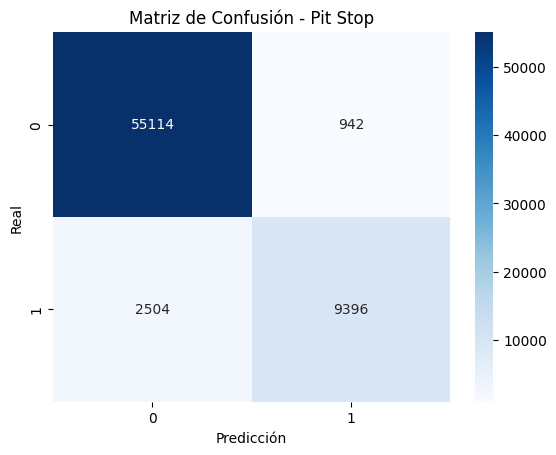

✅ Modelo y archivos guardados correctamente.


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pickle

# 1. Cargar datos
df = pd.read_csv("Datos_definitivos.csv")

# 2. Convertir tiempos a segundos
for col in ["LapTime", "Sector1Time", "Sector2Time", "Sector3Time"]:
    df[col] = pd.to_timedelta(df[col], errors="coerce").dt.total_seconds()

# 3. Generar columna binaria: ¿hará pit stop en la próxima vuelta?
df = df.sort_values(by=["Driver", "EventName", "LapNumber"])
df["NextStint"] = df.groupby(["Driver", "EventName"])["Stint"].shift(-1)
df["WillPitNextLap"] = (df["Stint"] != df["NextStint"]).astype(int)

# 4. Calcular velocidad media
df["MeanSpeed"] = df[["SpeedI1", "SpeedI2", "SpeedFL", "SpeedST"]].mean(axis=1)

# 5. Selección de variables (SIN FreshTyre y SIN Rainfall)
features = [
    "LapNumber", "LapTime", "TyreLife", "MeanSpeed",
    "AirTemp", "TrackTemp", "Pressure", "Humidity", "WindSpeed",
    "Compound", "Team", "Driver", "EventName"
]
target = "WillPitNextLap"

df_model = df[features + [target]].dropna().copy()

# 6. Codificar categóricas
categorical = ["Compound", "Team", "Driver", "EventName"]
label_encoders = {}
for col in categorical:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    label_encoders[col] = le

# 7. Separar variables y target
X = df_model[features]
y = df_model[target]

# 8. Dividir en entrenamiento y test
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# 9. Normalizar numéricas
numerical = X.select_dtypes(include=["float64", "int64"]).columns.difference(categorical)
scaler = StandardScaler()
X_train[numerical] = scaler.fit_transform(X_train[numerical])
X_test[numerical] = scaler.transform(X_test[numerical])

# 10. Entrenar modelo
clf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced")
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

# 11. Evaluación
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión - Pit Stop")
plt.show()

# 12. Guardar el modelo y componentes para Streamlit
with open("model_pitstop.pkl", "wb") as f:
    pickle.dump(clf, f)

with open("scaler_pitstop.pkl", "wb") as f:
    pickle.dump(scaler, f)

with open("label_encoders_pitstop.pkl", "wb") as f:
    pickle.dump(label_encoders, f)

with open("features_pitstop.pkl", "wb") as f:
    pickle.dump(features, f)

print("✅ Modelo y archivos guardados correctamente.")


In [ ]:
import pickle
features = pickle.load(open("features_pitstop.pkl", "rb"))
print(features)


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

y_proba = clf.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("Curva ROC")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
import pandas as pd
import seaborn as sns

importances = clf.feature_importances_
feat_df = pd.DataFrame({"Feature": X.columns, "Importance": importances})
feat_df = feat_df.sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=feat_df)
plt.title("Importancia de variables - Pit Stop Prediction")
plt.tight_layout()
plt.show()


In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df_model.corr(), annot=True, cmap="coolwarm")
plt.title("Correlación entre variables")
plt.tight_layout()
plt.show()


In [ ]:
sns.histplot(data=df[df["WillPitNextLap"] == 1], x="LapNumber", bins=30, kde=True)
plt.title("Distribución de vueltas con pit stops")
plt.xlabel("Número de vuelta")
plt.ylabel("Frecuencia")
plt.show()


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Asegurarse de tener la columna WillPitNextLap
# (1 si el piloto hace parada en la vuelta siguiente)
pit_counts = df[df["WillPitNextLap"] == 1].groupby("EventName").size().sort_values(ascending=False)

# Graficar
plt.figure(figsize=(12, 6))
sns.barplot(x=pit_counts.values, y=pit_counts.index, palette="Blues_r")
plt.title("Número de Pit Stops por Carrera")
plt.xlabel("Número de Pit Stops")
plt.ylabel("Carrera (EventName)")
plt.tight_layout()
plt.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.show()


In [ ]:
df["Season_Event"] = df["Season"].astype(str) + " - " + df["EventName"]
# Filtrar solo vueltas con pit stop próximo
pit_counts = df[df["WillPitNextLap"] == 1].groupby("Season_Event").size().sort_values(ascending=False)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 10))
sns.barplot(y=pit_counts.index, x=pit_counts.values, palette="crest")
plt.title("Número de Pit Stops por Carrera y Temporada")
plt.xlabel("Número de Pit Stops")
plt.ylabel("Carrera (Temporada - Evento)")
plt.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


### Probamos XGBoost

In [ ]:
pip install xgboost


In [ ]:
import pandas as pd
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cargar y preparar datos
df = pd.read_csv("Datos_definitivos.csv")

# Convertir tiempos a segundos
for col in ["LapTime", "Sector1Time", "Sector2Time", "Sector3Time"]:
    df[col] = pd.to_timedelta(df[col], errors="coerce").dt.total_seconds()

# Generar columna objetivo binaria: ¿hará pit stop en la próxima vuelta?
df = df.sort_values(by=["Driver", "EventName", "LapNumber"])
df["NextStint"] = df.groupby(["Driver", "EventName"])["Stint"].shift(-1)
df["WillPitNextLap"] = (df["Stint"] != df["NextStint"]).astype(int)

# Calcular velocidad media
df["MeanSpeed"] = df[["SpeedI1", "SpeedI2", "SpeedFL", "SpeedST"]].mean(axis=1)

# Variables
features = [
    "LapNumber", "LapTime", "TyreLife", "MeanSpeed", "FreshTyre",
    "AirTemp", "TrackTemp", "Pressure", "Humidity", "WindSpeed", "Rainfall",
    "Compound", "Team", "Driver", "EventName"
]
target = "WillPitNextLap"

df_model = df[features + [target]].dropna().copy()

# Codificar categóricas
categorical_cols = ["Compound", "Team", "Driver", "EventName"]
for col in categorical_cols:
    df_model[col] = LabelEncoder().fit_transform(df_model[col])

# Separar variables
X = df_model[features]
y = df_model[target]

# División
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# Escalado de numéricas
numerical = X.select_dtypes(include=["float64", "int64"]).columns.difference(categorical_cols)
scaler = StandardScaler()
X_train[numerical] = scaler.fit_transform(X_train[numerical])
X_test[numerical] = scaler.transform(X_test[numerical])

# Modelo XGBoost
model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predicción y métricas
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_proba))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de Confusión - XGBoost")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - XGBoost")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd

importances = model.feature_importances_
feat_imp = pd.DataFrame({"Feature": X.columns, "Importance": importances}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=feat_imp, palette="viridis")
plt.title("Importancia de Variables - XGBoost")
plt.tight_layout()
plt.show()


In [ ]:
sns.histplot(y_proba, bins=40, kde=True, color='purple')
plt.title("Distribución de Probabilidades - XGBoost")
plt.xlabel("Probabilidad de Pit Stop")
plt.ylabel("Frecuencia")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_proba)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall - XGBoost")
plt.grid(True)
plt.tight_layout()
plt.show()


Addressing Imbalance: Both models seem to be using class_weight="balanced" or similar internal handling (XGBoost can also handle imbalance via parameters). This is a good practice to prevent the model from simply predicting the majority class all the time.
Which is Better? You need to directly compare the key metrics, especially for Class 1 (pit stops), and the AUC/AUPRC between the Random Forest and XGBoost models.
Look at the F1-score for class 1. Higher is better.
Look at the AUC. Higher is better.
Look at the confusion matrices. Which model has fewer False Negatives (missed pit stops)? Which has fewer False Positives (false alarms)? The relative importance of these errors depends on the application (is it worse to miss a pit stop or send a false alert?).
The Precision-Recall curve comparison for XGBoost vs. RF would be very informative for this imbalanced problem.

## LightGBM

LightGBM es un algoritmo de boosting como XGBoost pero:

Más rápido y eficiente con datasets grandes,

Mejor manejo de variables categóricas codificadas,

Requiere menos memoria y suele converger más rápido.

In [ ]:
pip install lightgbm


In [ ]:
import pandas as pd
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score, roc_curve, precision_recall_curve
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cargar y preparar datos
df = pd.read_csv("Datos_definitivos.csv")

# Convertir tiempos a segundos
for col in ["LapTime", "Sector1Time", "Sector2Time", "Sector3Time"]:
    df[col] = pd.to_timedelta(df[col], errors="coerce").dt.total_seconds()

# Generar columna objetivo binaria
df = df.sort_values(by=["Driver", "EventName", "LapNumber"])
df["NextStint"] = df.groupby(["Driver", "EventName"])["Stint"].shift(-1)
df["WillPitNextLap"] = (df["Stint"] != df["NextStint"]).astype(int)

# Calcular velocidad media
df["MeanSpeed"] = df[["SpeedI1", "SpeedI2", "SpeedFL", "SpeedST"]].mean(axis=1)

# Variables
features = [
    "LapNumber", "LapTime", "TyreLife", "MeanSpeed", "FreshTyre",
    "AirTemp", "TrackTemp", "Pressure", "Humidity", "WindSpeed", "Rainfall",
    "Compound", "Team", "Driver", "EventName"
]
target = "WillPitNextLap"

df_model = df[features + [target]].dropna().copy()

# Codificar categóricas
categorical_cols = ["Compound", "Team", "Driver", "EventName"]
for col in categorical_cols:
    df_model[col] = LabelEncoder().fit_transform(df_model[col])

# Separar variables
X = df_model[features]
y = df_model[target]

# División train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# Escalado solo columnas numéricas
numerical_cols = X.select_dtypes(include=["float64", "int64"]).columns.difference(categorical_cols)
scaler = StandardScaler()
X_train.loc[:, numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test.loc[:, numerical_cols] = scaler.transform(X_test[numerical_cols])

# 2. Inicializar modelos
model_lgbm = LGBMClassifier(n_estimators=100, random_state=42, class_weight="balanced")
model_rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced")
model_xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

# 3. Entrenar
model_lgbm.fit(X_train, y_train)
model_rf.fit(X_train, y_train)
model_xgb.fit(X_train, y_train)

# 4. Predicciones y probabilidades
probs_lgbm = model_lgbm.predict_proba(X_test)[:,1]
probs_rf = model_rf.predict_proba(X_test)[:,1]
probs_xgb = model_xgb.predict_proba(X_test)[:,1]

preds_lgbm = model_lgbm.predict(X_test)
preds_rf = model_rf.predict(X_test)
preds_xgb = model_xgb.predict(X_test)

# 5. Métricas
def print_metrics(name, y_true, y_pred, y_prob):
    print(f"🔍 {name} - Classification Report")
    print(classification_report(y_true, y_pred))
    print(f"AUC: {roc_auc_score(y_true, y_prob):.4f}")
    print(f"F1-score: {f1_score(y_true, y_pred):.4f}")
    print("-"*40)

print_metrics("LightGBM", y_test, preds_lgbm, probs_lgbm)
print_metrics("Random Forest", y_test, preds_rf, probs_rf)
print_metrics("XGBoost", y_test, preds_xgb, probs_xgb)

# 6. Matrices de confusión
fig, axes = plt.subplots(1, 3, figsize=(18,5))
for ax, model_name, preds in zip(axes, ["LightGBM", "Random Forest", "XGBoost"], [preds_lgbm, preds_rf, preds_xgb]):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
                xticklabels=["No Pit", "Pit"], yticklabels=["No Pit", "Pit"],
                ax=ax)
    ax.set_title(f"Matriz de Confusión - {model_name}")
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Real")
plt.tight_layout()
plt.show()

# 7. Curvas ROC
plt.figure(figsize=(10,4))
for probs, name in zip([probs_lgbm, probs_rf, probs_xgb], ["LightGBM", "Random Forest", "XGBoost"]):
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc_score = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc_score:.2f})')
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curvas ROC")
plt.legend()
plt.show()

# 8. Curvas Precision-Recall
plt.figure(figsize=(10,4))
for probs, name in zip([probs_lgbm, probs_rf, probs_xgb], ["LightGBM", "Random Forest", "XGBoost"]):
    prec, rec, _ = precision_recall_curve(y_test, probs)
    plt.plot(rec, prec, label=name)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curvas Precision-Recall")
plt.legend()
plt.show()

# 9. Distribución de probabilidades predichas
plt.figure(figsize=(10,4))
plt.hist(probs_lgbm, bins=30, alpha=0.5, label="LightGBM")
plt.hist(probs_rf, bins=30, alpha=0.5, label="Random Forest")
plt.hist(probs_xgb, bins=30, alpha=0.5, label="XGBoost")
plt.xlabel("Probabilidad predicha")
plt.ylabel("Frecuencia")
plt.title("Distribución de probabilidades predichas")
plt.legend()
plt.show()


### Probamos Una red Neuronal

In [ ]:
pip install tensorflow

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import roc_auc_score, f1_score, classification_report
import pandas as pd # Import pandas
import numpy as np # Import numpy
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder # Import necessary preprocessing tools

# --- Assume data loading and preprocessing up to X and y are done here ---
# (Keeping the previous data loading and preprocessing steps for completeness)

# 1. Cargar y preparar datos (Copying relevant parts from previous cells)
df = pd.read_csv("Datos_definitivos.csv")

# Convertir tiempos a segundos
for col in ["LapTime", "Sector1Time", "Sector2Time", "Sector3Time"]:
    # Use errors='coerce' to turn unparseable values into NaT/NaN
    df[col] = pd.to_timedelta(df[col], errors="coerce").dt.total_seconds()

# Generar columna objetivo binaria
df = df.sort_values(by=["Driver", "EventName", "LapNumber"])
df["NextStint"] = df.groupby(["Driver", "EventName"])["Stint"].shift(-1)
df["WillPitNextLap"] = (df["Stint"] != df["NextStint"]).astype(int)

# Calcular velocidad media
df["MeanSpeed"] = df[["SpeedI1", "SpeedI2", "SpeedFL", "SpeedST"]].mean(axis=1)

# Variables
features = [
    "LapNumber", "LapTime", "TyreLife", "MeanSpeed", "FreshTyre",
    "AirTemp", "TrackTemp", "Pressure", "Humidity", "WindSpeed", "Rainfall",
    "Compound", "Team", "Driver", "EventName"
]
target = "WillPitNextLap"

# Ensure the target column is included before dropping NaNs
df_model = df[features + [target]].dropna().copy()

# Codificar categóricas
categorical_cols = ["Compound", "Team", "Driver", "EventName"]
for col in categorical_cols:
    # Use try-except block in case a column doesn't exist after dropna
    if col in df_model.columns:
        df_model[col] = LabelEncoder().fit_transform(df_model[col])
    else:
        print(f"Warning: Categorical column '{col}' not found after dropping NaNs.")


# Separar variables
X = df_model[features]
y = df_model[target]

# División train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# Escalado solo columnas numéricas
# Recalculate numerical_cols based on X_train *after* LabelEncoding,
# as LabelEncoder outputs integers which should be scaled if they are not truly categorical indices.
# However, for Tree-based models, scaling labeled categorical features is often not necessary.
# For Neural Networks, scaling *all* numeric inputs (including encoded labels) is generally good practice.
numerical_cols_to_scale = X_train.select_dtypes(include=[np.number]).columns # Select all numeric types

scaler = StandardScaler()
# Use .copy() to avoid SettingWithCopyWarning when assigning scaled values
X_train.loc[:, numerical_cols_to_scale] = scaler.fit_transform(X_train[numerical_cols_to_scale])
X_test.loc[:, numerical_cols_to_scale] = scaler.transform(X_test[numerical_cols_to_scale])

# --- End of assumed data loading and preprocessing ---


# Explicitly convert X_train and X_test to numeric types, coercing errors
# This step helps catch any remaining non-numeric data before converting to NumPy
for col in X_train.columns:
    X_train[col] = pd.to_numeric(X_train[col], errors='coerce')
for col in X_test.columns:
    X_test[col] = pd.to_numeric(X_test[col], errors='coerce')

# After coercing, drop any rows that might have gotten NaNs from this process (though less likely after initial dropna)
X_train.dropna(inplace=True)
X_test.dropna(inplace=True)
# IMPORTANT: If dropping rows from X_train/X_test, you MUST also drop the corresponding rows from y_train/y_test
# A safer approach is to handle NaNs *before* the train_test_split if possible.
# Given the traceback indicates an object dtype error at the fit stage,
# ensuring all dtypes are numeric *before* conversion to numpy is the most direct fix.

# Convert to numpy arrays (Keras needs that)
# Ensure all columns are numeric before converting to numpy
# Select only columns with numeric dtypes
X_train_nn = X_train.select_dtypes(include=[np.number]).values
X_test_nn = X_test.select_dtypes(include=[np.number]).values

# Ensure y is also aligned with X_train/X_test after any potential row drops (if implemented)
# In this corrected code, we added the numeric conversion *after* split, so need to re-align y
# based on the indices of the cleaned X_train/X_test.
# A better way is to do the numeric conversion *before* the split.
# Let's revise to do the numeric conversion before the split and drop NaNs then.

# --- Revised Data Preparation to ensure numeric types BEFORE split ---

df = pd.read_csv("Datos_definitivos.csv")

for col in ["LapTime", "Sector1Time", "Sector2Time", "Sector3Time"]:
    df[col] = pd.to_timedelta(df[col], errors="coerce").dt.total_seconds()

df = df.sort_values(by=["Driver", "EventName", "LapNumber"])
df["NextStint"] = df.groupby(["Driver", "EventName"])["Stint"].shift(-1)
df["WillPitNextLap"] = (df["Stint"] != df["NextStint"]).astype(int)
df["MeanSpeed"] = df[["SpeedI1", "SpeedI2", "SpeedFL", "SpeedST"]].mean(axis=1)

features = [
    "LapNumber", "LapTime", "TyreLife", "MeanSpeed", "FreshTyre",
    "AirTemp", "TrackTemp", "Pressure", "Humidity", "WindSpeed", "Rainfall",
    "Compound", "Team", "Driver", "EventName"
]
target = "WillPitNextLap"

df_model = df[features + [target]].dropna().copy()

categorical_cols = ["Compound", "Team", "Driver", "EventName"]
for col in categorical_cols:
     if col in df_model.columns:
        df_model[col] = LabelEncoder().fit_transform(df_model[col])


# Explicitly convert all potential feature columns to numeric, coercing errors
# This should be done *before* splitting and scaling
for col in features:
     if col in df_model.columns: # Check if column exists
        df_model[col] = pd.to_numeric(df_model[col], errors='coerce')

# Drop rows that might have introduced NaNs during numeric conversion
df_model.dropna(subset=features + [target], inplace=True)


# Separate features and target AFTER cleaning
X = df_model[features]
y = df_model[target]


# Division train/test (stratify if needed for classification target 'y')
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)


# Escalado solo columnas numéricas (all columns in X should now be numeric)
# Select all columns in X as numeric for scaling for the NN
numerical_cols_to_scale = X_train.columns # All columns in X_train should now be numeric

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[numerical_cols_to_scale])
X_test_scaled = scaler.transform(X_test[numerical_cols_to_scale])


# Convert scaled data to numpy arrays
X_train_nn = X_train_scaled
X_test_nn = X_test_scaled
y_train_nn = y_train.values # y was already Series, get values
y_test_nn = y_test.values

# --- End of Revised Data Preparation ---


# 1. Build the model
model_nn = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_nn.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')  # Output layer for binary classification
])

model_nn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['AUC'])

# 2. Train with EarlyStopping to avoid overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model_nn.fit(
    X_train_nn, y_train_nn,
    validation_split=0.2, # This splits 20% of the *training* data for validation
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=2
)

# 3. Predict probabilities and hard predictions
probs_nn = model_nn.predict(X_test_nn).flatten()
preds_nn = (probs_nn >= 0.5).astype(int)

# 4. Metrics
print("🔍 Neural Network - Classification Report")
print(classification_report(y_test_nn, preds_nn))
print(f"AUC: {roc_auc_score(y_test_nn, probs_nn):.4f}")
print(f"F1-score: {f1_score(y_test_nn, preds_nn):.4f}")

# 5. Compare with Random Forest (assuming model_rf trained earlier)
# Make sure model_rf is accessible and trained in the current environment.
# Need to use the original scaled X_test data (without the extra numeric coercion step)
# that was used for training and evaluating model_rf previously.
# However, since we revised the preprocessing, let's re-train model_rf with the *newly* scaled data.
# This is safer to ensure consistency.

# Re-train model_rf using the scaled data prepared for the NN
model_rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced")
model_rf.fit(X_train_nn, y_train_nn) # Train RF on scaled data

probs_rf = model_rf.predict_proba(X_test_nn)[:,1] # Use scaled test data
preds_rf = model_rf.predict(X_test_nn) # Use scaled test data

print("\n🔍 Random Forest - Classification Report (on scaled data)")
print(classification_report(y_test_nn, preds_rf))
print(f"AUC: {roc_auc_score(y_test_nn, probs_rf):.4f}")
print(f"F1-score: {f1_score(y_test_nn, preds_rf):.4f}")

# 6. Optional: ROC curves comparison
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

fpr_nn, tpr_nn, _ = roc_curve(y_test_nn, probs_nn)
fpr_rf, tpr_rf, _ = roc_curve(y_test_nn, probs_rf) # Use y_test_nn consistently

plt.plot(fpr_nn, tpr_nn, label='Neural Network')
plt.plot(fpr_rf, tpr_rf, label='Random Forest')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

**---------------------------------------------------------------------------------------------------------------**

**------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------**

#VISUALIZACIONES ADICCIONALES



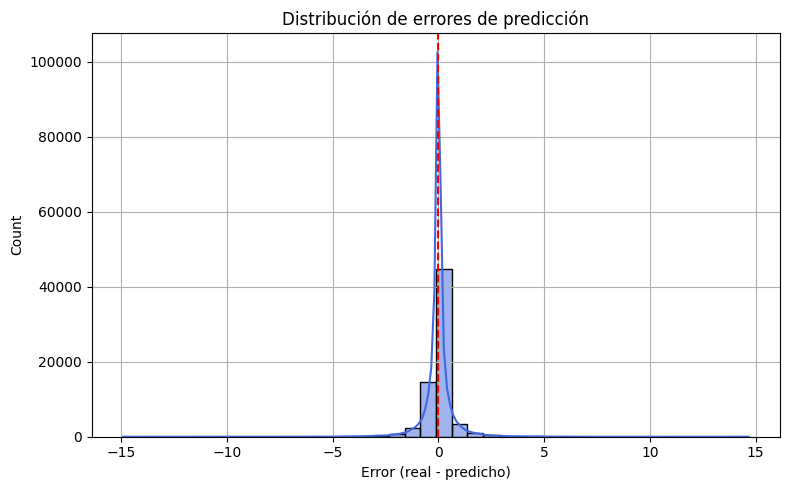

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np # Import numpy if you haven't already

# Assuming y_test and y_pred from the Random Forest Regressor are available

# Calculate the errors
errors = y_test - y_pred

# Create the histogram
plt.figure(figsize=(8, 5))
sns.histplot(errors, bins=40, kde=True, color="royalblue")
plt.axvline(0, color='red', linestyle='--') # Add a vertical line at 0 for reference
plt.title("Distribución de errores de predicción")
plt.xlabel("Error (real - predicho)")
plt.grid(True)
plt.tight_layout()
plt.show()

/tmp/ipython-input-5-879837025.py:17: DtypeWarning: Columns (29) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Datos_definitivos.csv")


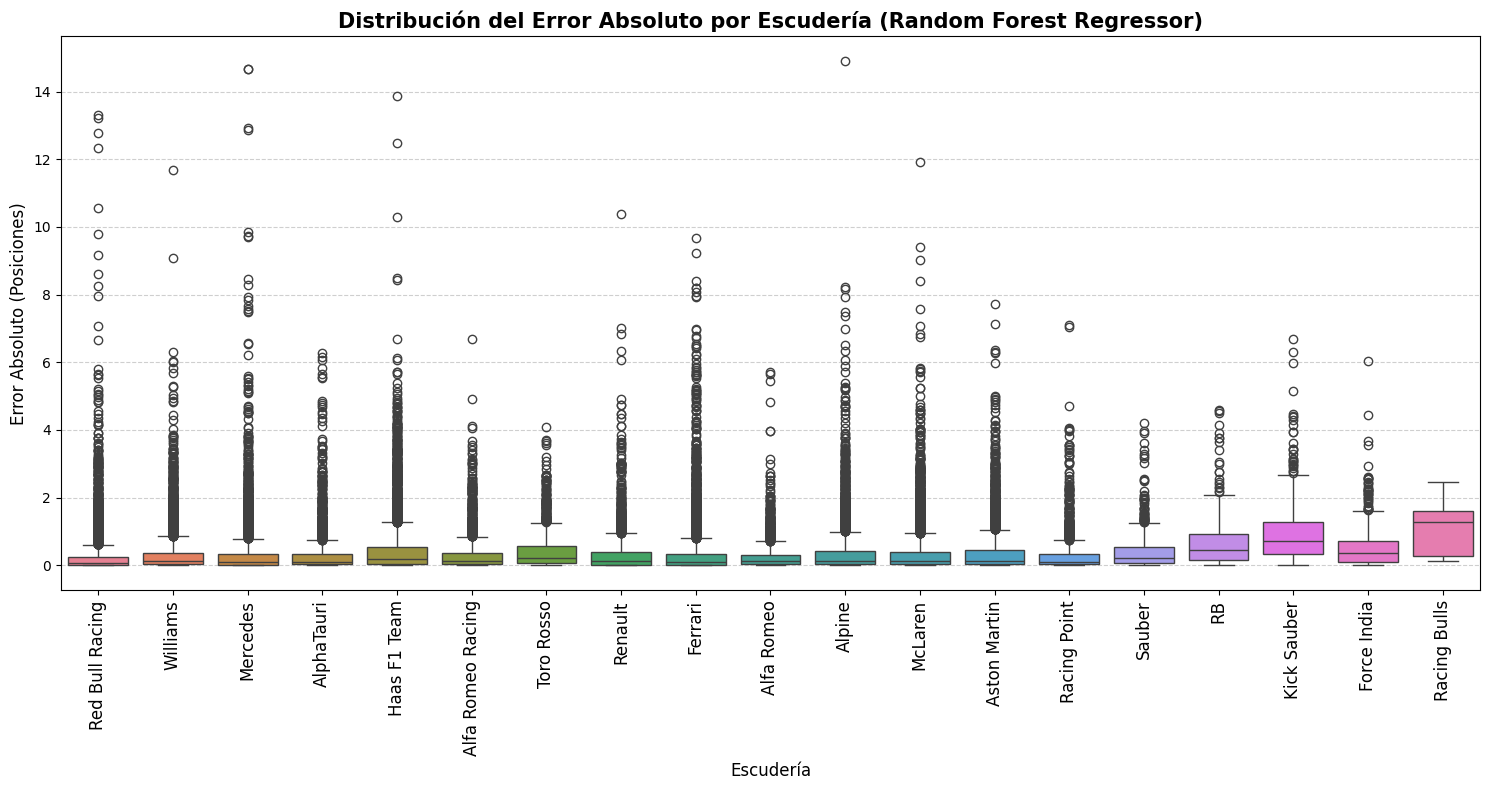

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor

# Assuming you want to use the same model architecture as your successful training
# in your notebook. We will now explicitly train it in this cell.

# --- Re-create necessary data for plotting ---
# It's safer to recreate the test set structure to ensure alignment
# with the predictions, in case variables were overwritten.

# Load and prepare data up to the point of splitting
df = pd.read_csv("Datos_definitivos.csv")
for col in ["LapTime", "Sector1Time", "Sector2Time", "Sector3Time"]:
    df[col] = pd.to_timedelta(df[col], errors="coerce").dt.total_seconds()

features = [
    "LapNumber", "LapTime", "TyreLife",
    "SpeedI1", "SpeedI2", "SpeedFL", "SpeedST",
    "AirTemp", "Humidity", "Pressure", "TrackTemp", "WindSpeed",
    "Compound", "Team", "Driver", "EventName"
]
target = "Position"

df_model = df[features + [target]].dropna().copy()

# Keep the original 'Team' column before encoding for plotting
df_model['Original_Team'] = df_model['Team']

# Codificar variables categóricas
categorical_cols = ["Compound", "Team", "Driver", "EventName"]
label_encoders = {} # Store encoders if you need them elsewhere, but not strictly for this plot
for col in categorical_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    label_encoders[col] = le # Optional: save encoders

# Separate features and target
X = df_model[features]
y = df_model[target]

# Split data (using the same random_state as your training split)
X_train, X_test_plot, y_train, y_test_plot = train_test_split(X, y, test_size=0.2, random_state=42)

# Identify numerical columns after encoding
numerical_cols = X_train.select_dtypes(include=["float64", "int64"]).columns.difference(categorical_cols) # Use X_train here to be safe

# Initialize and fit the scaler on the training data
scaler = StandardScaler()
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols]) # Fit on train
# Transform the test data using the scaler fitted on the training data
X_test_plot[numerical_cols] = scaler.transform(X_test_plot[numerical_cols]) # Transform test

# --- Explicitly re-train the model in this cell ---
# Initialize the model with the desired hyperparameters
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# Train the model using the training data prepared in this cell
model.fit(X_train, y_train)

# --- After the model is fitted ---

# Make predictions on the scaled test set prepared in this cell
y_pred = model.predict(X_test_plot)

# --- Create the boxplot ---

# 1. Calculate absolute errors
absolute_errors = np.abs(y_test_plot - y_pred)

# 2. Create a dataframe with the absolute errors and the corresponding team
# Use the index of the split test set (X_test_plot) to get the original team names
# Note: Ensure the index of error_df aligns with the index of df_model used for Original_Team
# Both absolute_errors and df_model.loc[X_test_plot.index, 'Original_Team'] should have the same index from the split.
error_df = pd.DataFrame({
    "Absolute_Error": absolute_errors,
    # Get the original team name from the full df_model using the index of the test split
    "Team": df_model.loc[y_test_plot.index, 'Original_Team'] # Use y_test_plot.index as it's guaranteed to align with absolute_errors
})


# 3. Create the boxplot
plt.figure(figsize=(15, 8)) # Increased figure size to accommodate the legend and potentially more teams
sns.boxplot(x="Team", y="Absolute_Error", data=error_df,
            hue="Team",  # Use 'hue' to assign different colors based on 'Team'
            legend=False) # Typically, with many categories on the x-axis, a separate legend isn't needed as the x-labels serve as the key. Set to True if you prefer a legend.

plt.title("Distribución del Error Absoluto por Escudería (Random Forest Regressor)",fontsize=15, fontweight='bold' )
plt.xlabel("Escudería" , fontsize=12)
plt.ylabel("Error Absoluto (Posiciones)",fontsize=12)
plt.xticks(rotation=90, fontsize=12) # Rotate team names for better readability
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.tight_layout() # Adjust layout to prevent labels overlapping
plt.show()

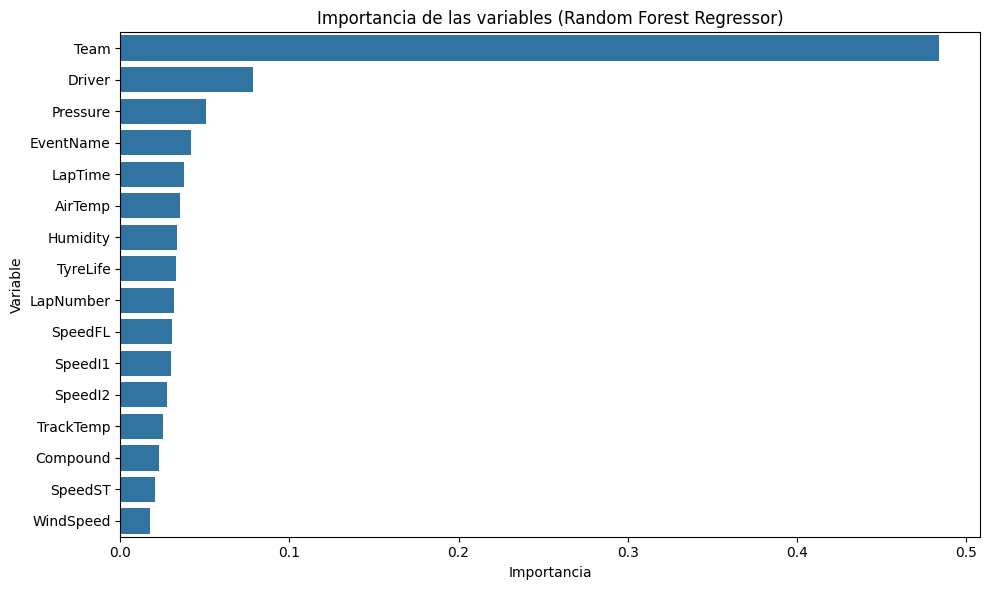

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Asegúrate de que 'model' (tu RandomForestRegressor entrenado) y 'X' (los features antes de escalar)
# estén disponibles en tu entorno.

# Calcular la importancia de las variables
importances = model.feature_importances_

# Obtener los nombres de las columnas (features)
# Es crucial usar los nombres de las columnas del dataframe X original (antes del escalado),
# ya que el modelo RF usa el orden de las features de entrenamiento.
# Si X_train fue un numpy array después del escalado, necesitas los nombres de las columnas del DataFrame original X.
feature_names = X.columns

# Crear un DataFrame para visualizar la importancia
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

# Ordenar por importancia descendente
importance_df = importance_df.sort_values(by="Importance", ascending=False)

# Graficar la importancia de las variables
plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Feature", data=importance_df)
plt.title("Importancia de las variables (Random Forest Regressor)")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

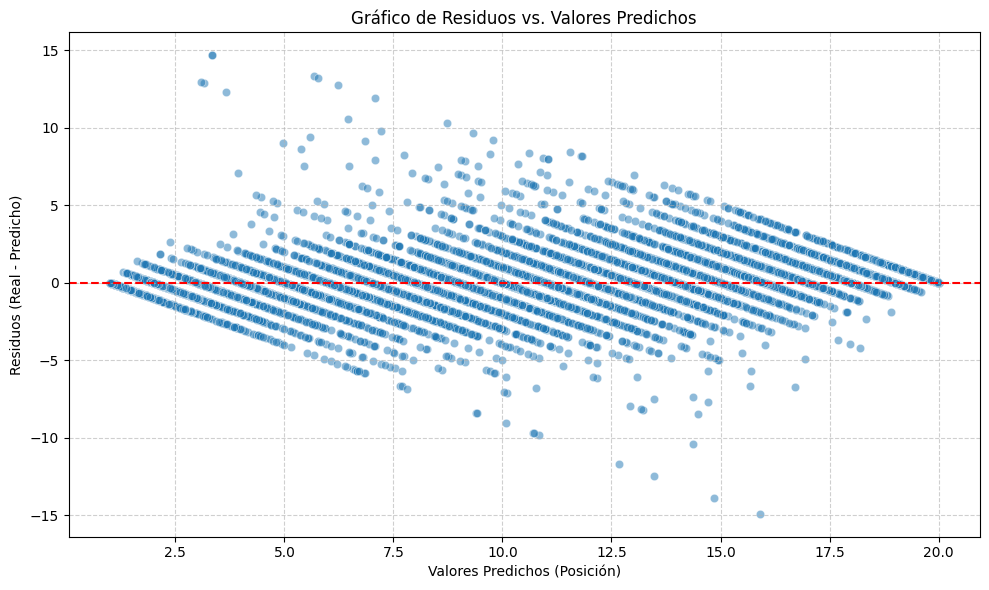

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np # Asegúrate de importar numpy

# Asumiendo que y_test_plot (los valores reales del conjunto de prueba)
# y y_pred (las predicciones para ese mismo conjunto de prueba)
# están disponibles después de entrenar y predecir con tu modelo de regresión.

# Calcular los residuos (errores)
residuals = y_test_plot - y_pred

# Crear el gráfico de Residuos vs. Valores Predichos
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.5) # x=valores predichos, y=residuos
plt.axhline(0, color='red', linestyle='--') # Línea de referencia en 0
plt.title("Gráfico de Residuos vs. Valores Predichos")
plt.xlabel("Valores Predichos (Posición)")
plt.ylabel("Residuos (Real - Predicho)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

/tmp/ipython-input-2-4027052088.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=feat_df, palette="viridis") # Usamos 'viridis' u otro cmap para colores


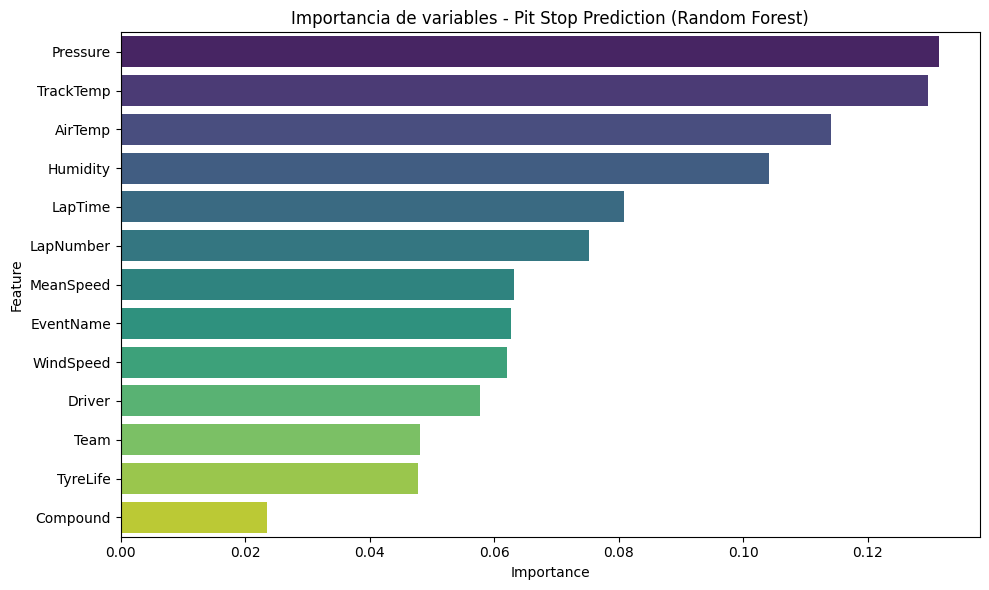

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Asumiendo que clf (el modelo RandomForestClassifier entrenado para pit stop)
# y X (los features usados para entrenar el modelo) ya existen en tu entorno

importances = clf.feature_importances_
feat_df = pd.DataFrame({"Feature": X.columns, "Importance": importances})
feat_df = feat_df.sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=feat_df, palette="viridis") # Usamos 'viridis' u otro cmap para colores
plt.title("Importancia de variables - Pit Stop Prediction (Random Forest)")
plt.tight_layout()
plt.show()

/tmp/ipython-input-3-1642506872.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pit_stops_por_equipo.values, y=pit_stops_por_equipo.index, palette="mako") # Puedes elegir otra paleta


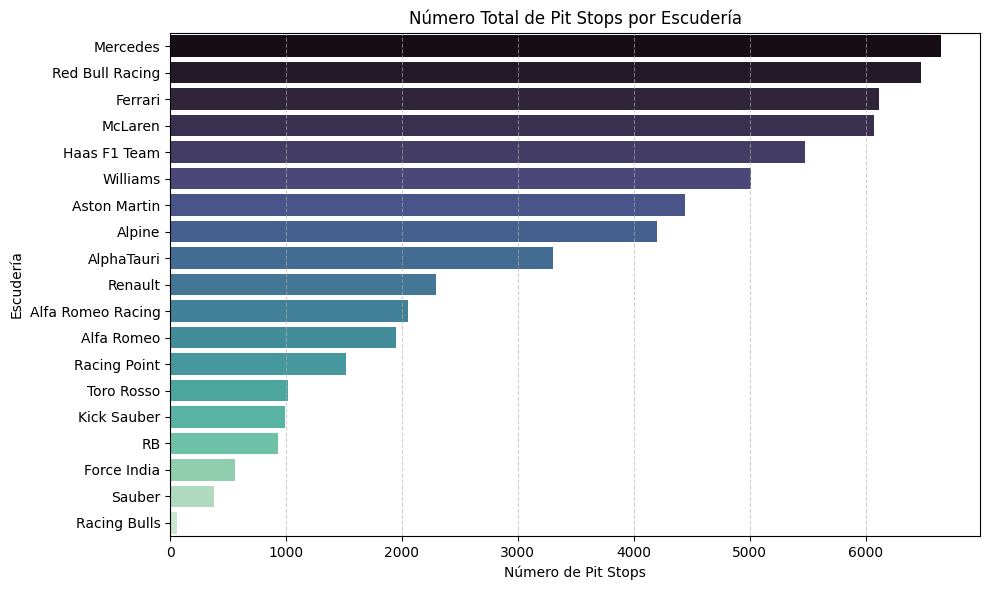

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Asegúrate de que df ya está cargado y preprocesado
# (incluyendo la creación de la columna 'WillPitNextLap')

# Contar pit stops por escudería
pit_stops_por_equipo = df[df["WillPitNextLap"] == 1].groupby("Team").size().sort_values(ascending=False)

# Graficar
plt.figure(figsize=(10, 6)) # Ajusta el tamaño según el número de equipos
sns.barplot(x=pit_stops_por_equipo.values, y=pit_stops_por_equipo.index, palette="mako") # Puedes elegir otra paleta
plt.title("Número Total de Pit Stops por Escudería")
plt.xlabel("Número de Pit Stops")
plt.ylabel("Escudería")
plt.grid(True, axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

/tmp/ipython-input-4-4250213875.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pit_stops_por_piloto.values, y=pit_stops_por_piloto.index, palette="rocket") # Puedes elegir otra paleta


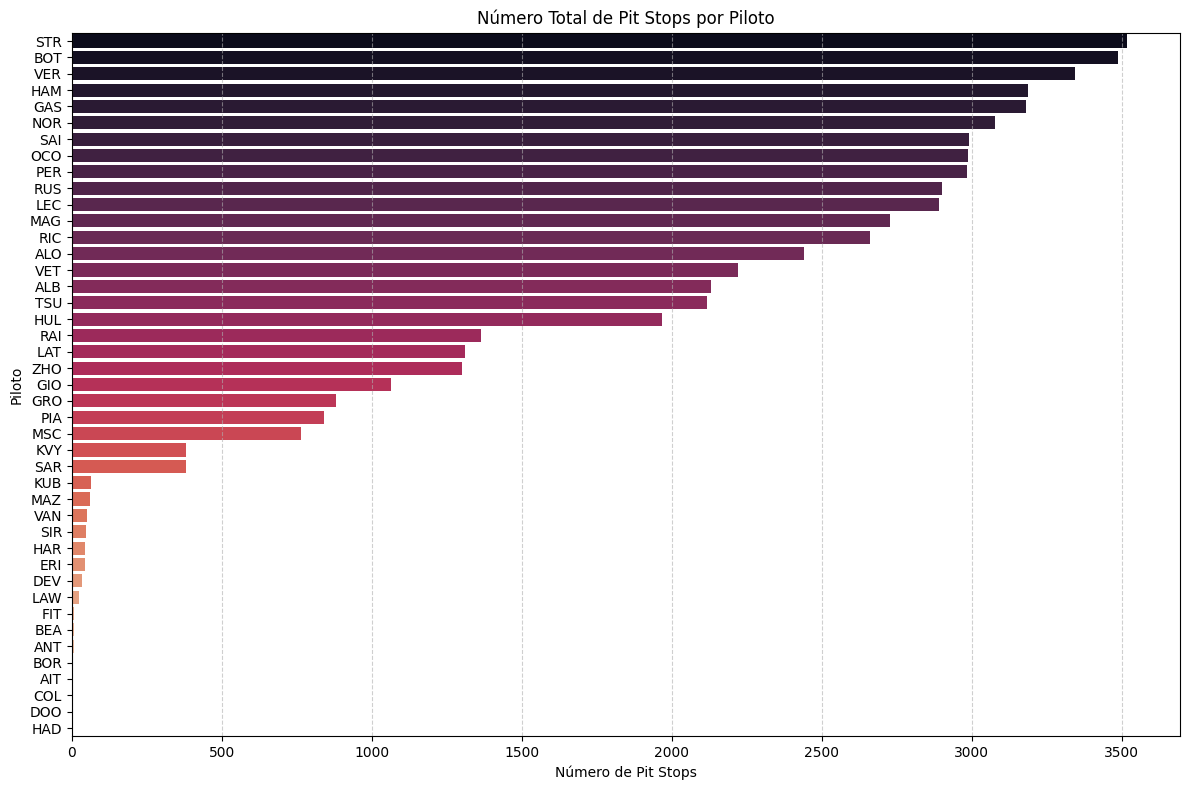

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Asegúrate de que df ya está cargado y preprocesado
# (incluyendo la creación de la columna 'WillPitNextLap')
# Basado en tu código anterior, df ya tiene esta columna.

# Contar pit stops por piloto
pit_stops_por_piloto = df[df["WillPitNextLap"] == 1].groupby("Driver").size().sort_values(ascending=False)

# Graficar
plt.figure(figsize=(12, 8)) # Ajusta el tamaño según el número de pilotos
sns.barplot(x=pit_stops_por_piloto.values, y=pit_stops_por_piloto.index, palette="rocket") # Puedes elegir otra paleta
plt.title("Número Total de Pit Stops por Piloto")
plt.xlabel("Número de Pit Stops")
plt.ylabel("Piloto")
plt.grid(True, axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

/tmp/ipython-input-7-1425457073.py:19: DtypeWarning: Columns (29) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Datos_definitivos.csv")
/tmp/ipython-input-7-1425457073.py:114: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Prob_PitStop_Pred", y="Team", data=results_df[results_df["Real_PitStop"] == 1], palette="Reds")


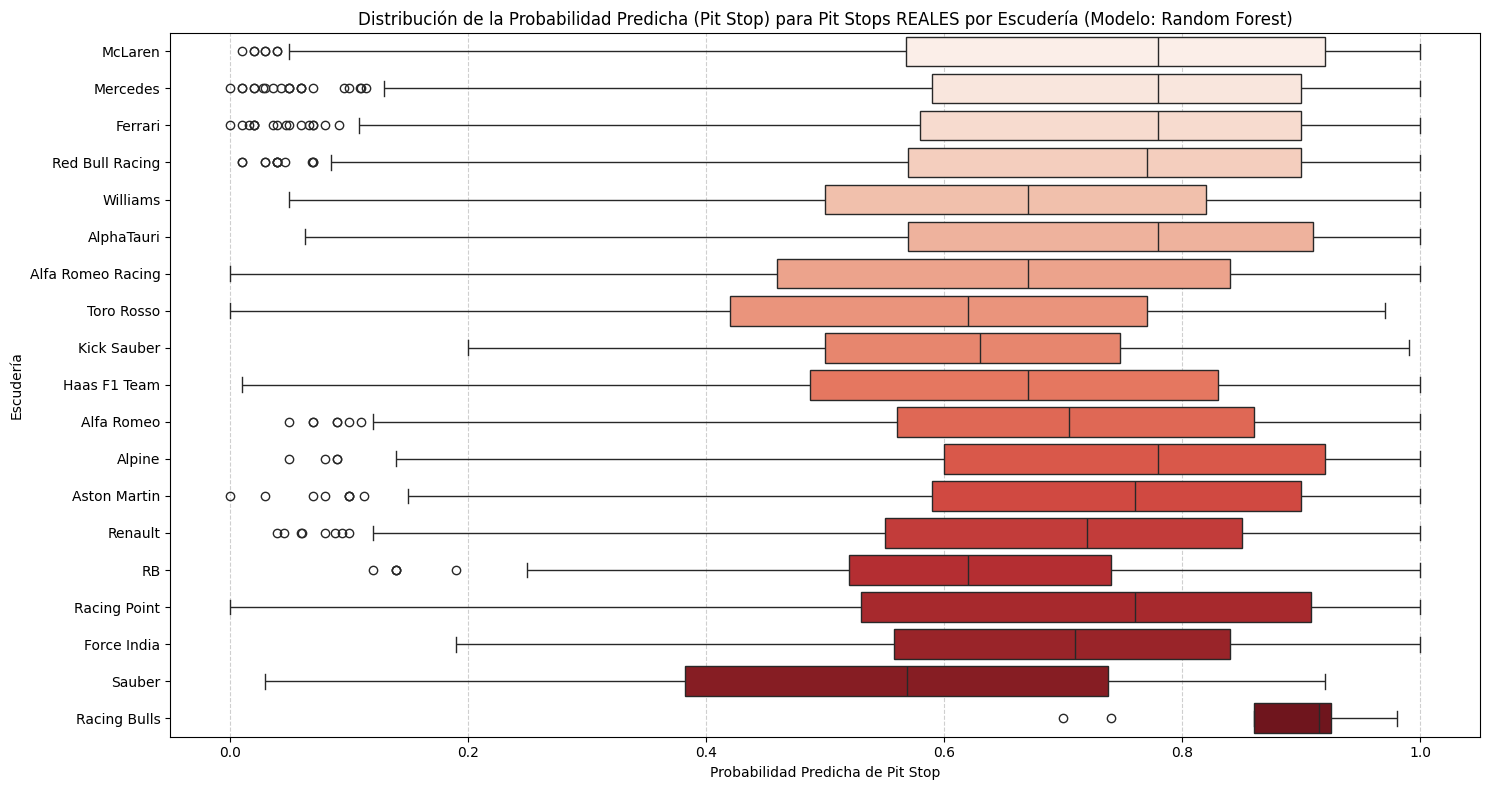

/tmp/ipython-input-7-1425457073.py:125: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Prob_PitStop_Pred", y="Team", data=results_df[results_df["Real_PitStop"] == 0], palette="Blues")


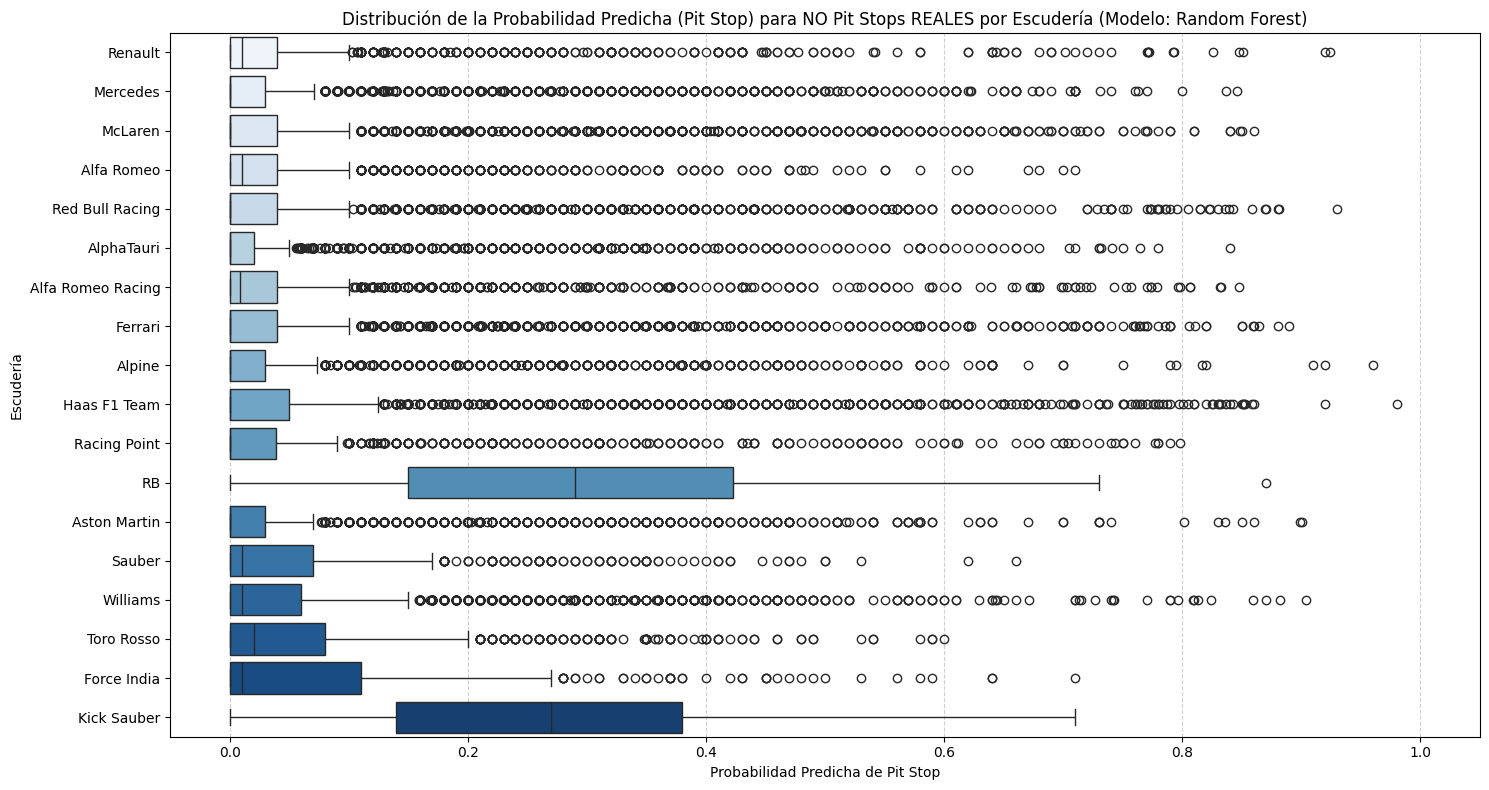

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
# Make sure you import the specific model you are using if it's not already in scope
from sklearn.ensemble import RandomForestClassifier # Assuming clf is a RandomForestClassifier

# --- Asegúrate de que estas variables existen en tu entorno y son correctas ---
# clf: Tu modelo RandomForestClassifier entrenado para pit stop
# X_test_scaled: El conjunto de prueba con features escalados y codificados (PUEDE contener más features)
# y_test: El target real (0 o 1) del conjunto de prueba
# df_test_original: Un DataFrame que contiene las columnas originales (incluyendo 'Team')
#                   para EXACTAMENTE las mismas filas que están en X_test_scaled y y_test.
#                   Si seguiste el código anterior para obtener test_indices, deberías tenerlo.

# If you need to recreate df_test_original based on the split:
# (Solo ejecuta esto si no estás seguro de tener df_test_original correcto)
# Cargar datos originales completos
df = pd.read_csv("Datos_definitivos.csv")
for col in ["LapTime", "Sector1Time", "Sector2Time", "Sector3Time"]:
    df[col] = pd.to_timedelta(df[col], errors="coerce").dt.total_seconds()

# Generar columna objetivo y features (debe coincidir con el entrenamiento)
df = df.sort_values(by=["Driver", "EventName", "LapNumber"])
df["NextStint"] = df.groupby(["Driver", "EventName"])["Stint"].shift(-1)
df["WillPitNextLap"] = (df["Stint"] != df["NextStint"]).astype(int)
df["MeanSpeed"] = df[["SpeedI1", "SpeedI2", "SpeedFL", "SpeedST"]].mean(axis=1)

# --- Define the features list *exactly* as it was when clf was trained ---
# Based on your earlier code for the Random Forest Classifier (clf),
# FreshTyre and Rainfall were *not* included in the 'features' list for clf training.
features_for_clf_training = [
    "LapNumber", "LapTime", "TyreLife", "MeanSpeed",
    "AirTemp", "TrackTemp", "Pressure", "Humidity", "WindSpeed",
    "Compound", "Team", "Driver", "EventName" # Note: No FreshTyre, Rainfall
]
target = "WillPitNextLap"

# Recreate df_model_original using the *full* features list that you later used (including FreshTyre, Rainfall)
# This is needed to correctly index df_test_original if it's based on the split indices
full_features_used_later = [
    "LapNumber", "LapTime", "TyreLife", "MeanSpeed", "FreshTyre",
    "AirTemp", "TrackTemp", "Pressure", "Humidity", "WindSpeed", "Rainfall",
    "Compound", "Team", "Driver", "EventName"
]
df_model_original = df[full_features_used_later + [target]].dropna().copy()

# Separate features and target using the *full* feature set to get the correct indices
X_full = df_model_original[full_features_used_later]
y_full = df_model_original[target]

# Perform the split using the *full* feature set to get the test indices for df_test_original
X_train_full, X_test_full, y_train, y_test = train_test_split(X_full, y_full, stratify=y_full, test_size=0.2, random_state=42)

# Use the index from the split to get the corresponding rows from the original model df
df_test_original = df_model_original.loc[X_test_full.index].copy()

# --- Now, prepare X_test_scaled by selecting the correct features ---
# Assuming X_test_scaled was generated from X_test_full AFTER scaling and encoding.
# If X_test_scaled is already a DataFrame, select the columns present in features_for_clf_training
# If X_test_scaled is a numpy array, you'll need to re-scale/re-encode just the features used for clf

# Let's re-create X_test_scaled specifically for the clf model features
# This requires the scaler and label_encoders used for clf training

# Re-do the preprocessing for clf's features list
df_model_clf = df[features_for_clf_training + [target]].dropna().copy()

# Codificar categóricas for clf's features
categorical_cols_clf = ["Compound", "Team", "Driver", "EventName"]
label_encoders_clf = {} # We need the encoders specific to the clf training data
for col in categorical_cols_clf:
    le = LabelEncoder()
    df_model_clf[col] = le.fit_transform(df_model_clf[col])
    label_encoders_clf[col] = le

# Separate variables and target using clf's feature set
X_clf = df_model_clf[features_for_clf_training]
y_clf = df_model_clf[target]

# Split data for clf (should result in the same indices as the full split if random_state is the same and data is not re-shuffled)
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(X_clf, y_clf, stratify=y_clf, test_size=0.2, random_state=42)

# Normalize numerical columns for clf's features
numerical_cols_clf = X_clf.select_dtypes(include=["float64", "int64"]).columns.difference(categorical_cols_clf)
scaler_clf = StandardScaler() # We need the scaler specific to clf training data
X_train_scaled_clf = X_train_clf.copy()
X_test_scaled_clf = X_test_clf.copy()

X_train_scaled_clf[numerical_cols_clf] = scaler_clf.fit_transform(X_train_clf[numerical_cols_clf])
X_test_scaled_clf[numerical_cols_clf] = scaler_clf.transform(X_test_clf[numerical_cols_clf])

# Now, X_test_scaled_clf is correctly prepared for the clf model.
# Make sure the y_test used for evaluation matches the split used for X_test_scaled_clf
# Since random_state is the same and stratify is used on the same target (implicitly), y_test_clf should be identical to y_test from the full split.

# --- Use the correctly prepared test set (X_test_scaled_clf) for prediction ---

# 1. Hacer predicciones de probabilidad
# Usa el modelo que quieres analizar: clf, model_xgb, o model_lgbm
# Use X_test_scaled_clf which has the correct features for the clf model
y_pred_proba = clf.predict_proba(X_test_scaled_clf)[:, 1] # Probabilidades para la clase 1 (Pit Stop)

# 2. Combinar los resultados
# Use y_test_clf for accurate alignment with X_test_scaled_clf
results_df = pd.DataFrame({
    "Team": df_test_original["Team"], # df_test_original already has the correct index
    "Real_PitStop": y_test_clf.values, # Use y_test from the clf split
    "Prob_PitStop_Pred": y_pred_proba
})

# 3. Boxplot de Probabilidad Predicha por Escudería para casos REALES DE PIT STOP
plt.figure(figsize=(15, 8))
sns.boxplot(x="Prob_PitStop_Pred", y="Team", data=results_df[results_df["Real_PitStop"] == 1], palette="Reds")
plt.title("Distribución de la Probabilidad Predicha (Pit Stop) para Pit Stops REALES por Escudería (Modelo: Random Forest)")
plt.xlabel("Probabilidad Predicha de Pit Stop")
plt.ylabel("Escudería")
plt.xlim(-0.05, 1.05) # Asegura que el eje x va de 0 a 1
plt.grid(True, axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# 4. Boxplot de Probabilidad Predicha por Escudería para casos REALES DE NO PIT STOP
plt.figure(figsize=(15, 8))
sns.boxplot(x="Prob_PitStop_Pred", y="Team", data=results_df[results_df["Real_PitStop"] == 0], palette="Blues")
plt.title("Distribución de la Probabilidad Predicha (Pit Stop) para NO Pit Stops REALES por Escudería (Modelo: Random Forest)")
plt.xlabel("Probabilidad Predicha de Pit Stop")
plt.ylabel("Escudería")
plt.xlim(-0.05, 1.05) # Asegura que el eje x va de 0 a 1
plt.grid(True, axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()